In [20]:
from ssa.market import LabourMarket, ExperimentLog
from ssa.agents import StaticAgent, LLMAgent, OracleAgent
from ssa.tasks.cipher import CipherAgent, CipherTask
from ssa.tasks import ProxyAgent, ProxyTask
from ssa.utils import init_azure_model
from tqdm import trange
import os


In [ ]:
task_ids = ["task_a", "task_b", "task_c"]
tasks = [ProxyTask(t) for t in task_ids]
for seed, task in enumerate(tasks):
    task.generate_ground_truth(seed=seed)


agents = []
agents.extend([StaticAgent(agent_id=f"test_{i}", tasks=tasks, model=None, verbose=False) for i in range(5)])

market = LabourMarket(tasks, agents, skill_phi=0.1, gumbel_t=0.5, rep_sensitivity=1)
for _ in trange(100):
    market.simulate_timestep()

exp_log = market.export()



2025-08-29 21:13:56.351 | INFO     | ssa.market:__init__:172 - Set up LabourMarket with 5 agents and 3 tasks. Initializing...
100%|██████████| 100/100 [00:00<00:00, 759.71it/s]


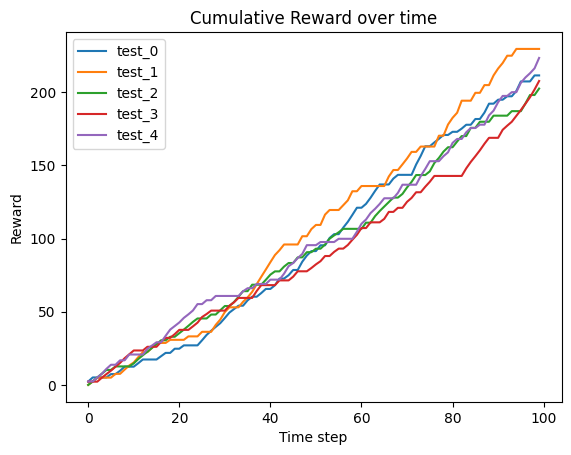

In [22]:
import matplotlib.pyplot as plt

plt.plot(exp_log.agent_total_rewards, label=exp_log.agent_ids)
plt.legend()
plt.xlabel('Time step')
plt.ylabel('Reward')
plt.title("Cumulative Reward over time")
plt.show()

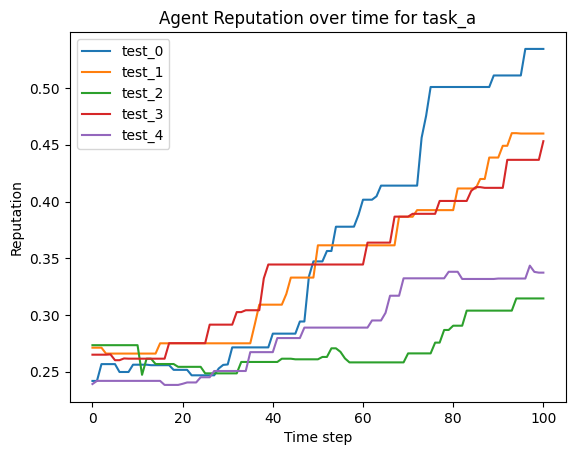

In [ ]:
plt.plot(exp_log.agent_reputation['task_a'], label=exp_log.agent_ids)
plt.legend()
plt.xlabel('Time step')
plt.ylabel('Reputation')
plt.title("Agent Reputation over time for task_a")
plt.show()

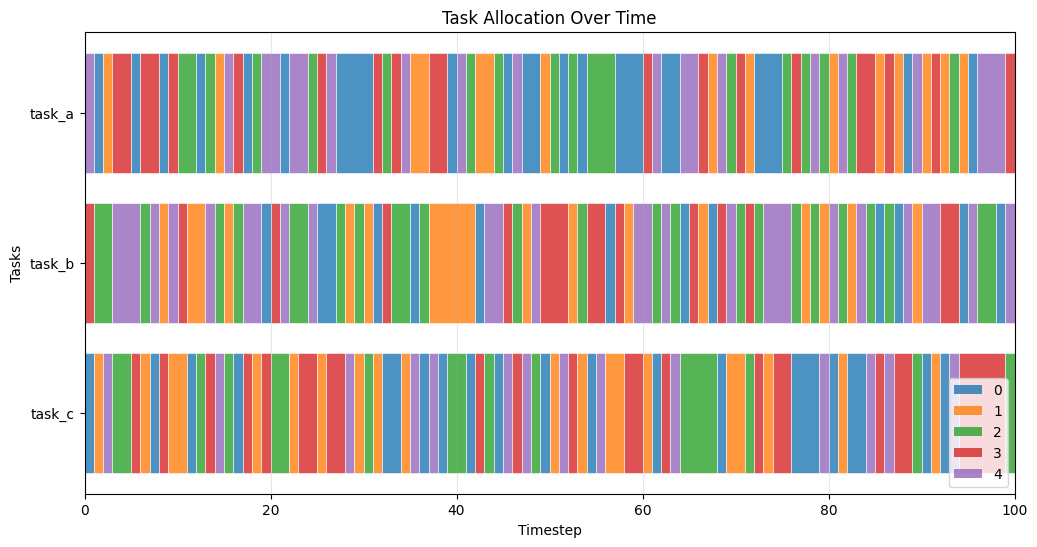

In [26]:
from ssa.plotting import plot_allocation

allocations = [history.matched_task_agent for history in exp_log.history]

fig, ax = plt.subplots(figsize=(12, 6))
ax = plot_allocation(ax, allocation=allocations)